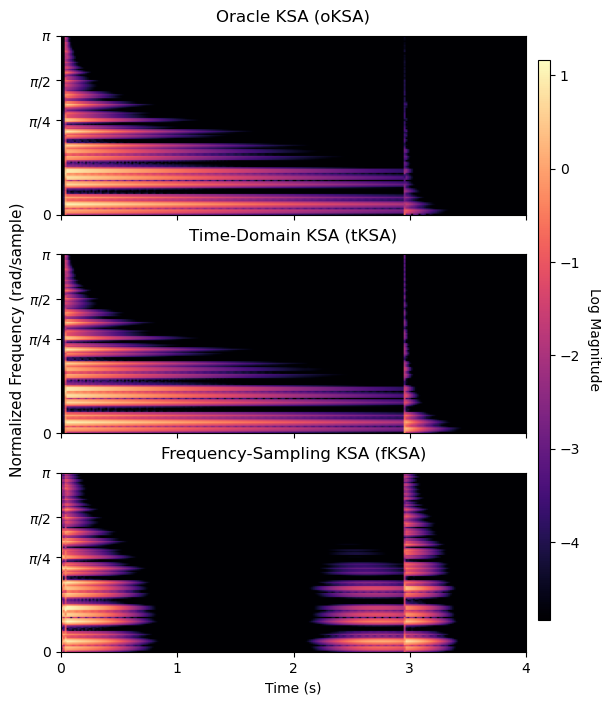

In [1]:
import torch
import torchaudio
import matplotlib.pyplot as plt
import numpy as np

from src.synths.synth import Synth, SynthConfig
from src.synths.ddsp import Implementation

# =============================================================================
# 1. CONFIGURATION & PARAMETERS
# =============================================================================
FS = 16000
DURATION = 4.0
NUM_SAMPLES = int(FS * DURATION)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- FIGURE & LABEL CONFIGURATION ---
FIG_WIDTH = 6.0
FIG_HEIGHT = 8.0
LABEL_FONTSIZE = 11
X_LABEL_Y_POS = 0.005  # Vertical position of "Time (s)"
Y_LABEL_X_POS = 0.04   # Horizontal position of "Normalized Frequency"
CBAR_X_POS = 0.92
H_SPACE = 0.22          # Space between plots

# Convert seconds to fractional time [0, 1] for the synth
t1_frac = 0.03 / DURATION
t2_frac = 2.96 / DURATION

# Setup the parameters for the two events [B, max_events] -> [1, 2]
params = {
    'exists':         torch.tensor([[1.0, 1.0]], device=DEVICE),
    'time':           torch.tensor([[t1_frac, t2_frac]], device=DEVICE),
    'f0':             torch.tensor([[110.0, 110.0]], device=DEVICE),
    'decay':          torch.tensor([[0.99, 0.9]], device=DEVICE),
    'a1':             torch.tensor([[0.12, 0.7]], device=DEVICE),
    'dynamic_level':  torch.tensor([[0.9, 0.2]], device=DEVICE),
    'burst_gain':     torch.tensor([[1.0, 1.0]], device=DEVICE),
    'pluck_position': torch.tensor([[0.25, 0.25]], device=DEVICE)
}

# =============================================================================
# 2. INITIALIZE SYNTHESIZERS
# =============================================================================
# Time-Domain Synth
synth_td = Synth(SynthConfig(
    num_samples=NUM_SAMPLES,
    fs=FS,
    implementation=Implementation.TIME_DOMAIN
)).to(DEVICE)

# Frequency-Sampling
synth_fs = Synth(SynthConfig(
    num_samples=NUM_SAMPLES,
    fs=FS,
    implementation=Implementation.FREQUENCY_SAMPLING,
    n_fft=16384,
    hop_length=256,
    use_lti=False
)).to(DEVICE)

# =============================================================================
# 3. GENERATE AUDIO
# =============================================================================
with torch.no_grad():
    audio_oracle, _ = synth_td.oracle_synth(params)
    audio_td, _ = synth_td(params)
    audio_fs, _ = synth_fs(params)

# =============================================================================
# 4. COMPUTE MEL-SPECTROGRAMS
# =============================================================================
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=FS,
    n_fft=528,
    hop_length=256,
    n_mels=128,
    f_min=32.0,
    f_max=8000.0,
    norm="slaney",
    mel_scale="slaney"
).to(DEVICE)

def get_log_mel(audio_tensor):
    mel = mel_transform(audio_tensor.squeeze(0))
    log_mel = torch.log10(mel + 1e-9)
    return log_mel.cpu().numpy()

spec_oracle = get_log_mel(audio_oracle)
spec_td = get_log_mel(audio_td)
spec_fs = get_log_mel(audio_fs)

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(FIG_WIDTH, FIG_HEIGHT), sharex=True, sharey=True)
fig.subplots_adjust(hspace=H_SPACE)
specs = [
    (spec_oracle, "Oracle KSA (oKSA)"),
    (spec_td, "Time-Domain KSA (tKSA)"),
    (spec_fs, "Frequency-Sampling KSA (fKSA)")
]

vmax = max(spec_oracle.max(), spec_td.max(), spec_fs.max())

DYNAMIC_RANGE_BELS = 6.0
vmin = vmax - DYNAMIC_RANGE_BELS
spec_oracle = np.clip(spec_oracle, vmin, vmax)
spec_td = np.clip(spec_td, vmin, vmax)
spec_fs = np.clip(spec_fs, vmin, vmax)

f_min, f_max = 32.0, 8000.0
def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

m_min, m_max = hz_to_mel(f_min), hz_to_mel(f_max)

norm_freq_ticks = np.array([0.0, 0.25, 0.5, 1.0])
hz_ticks = norm_freq_ticks * f_max
mel_ticks = hz_to_mel(hz_ticks)

bin_ticks = 128 * (mel_ticks - m_min) / (m_max - m_min)
bin_ticks[0] = 0

pi_labels = ["0", r"$\pi/4$", r"$\pi/2$", r"$\pi$"]
fig.supylabel("Normalized Frequency (rad/sample)", fontsize=LABEL_FONTSIZE, x=Y_LABEL_X_POS)

for ax, (spec, title) in zip(axes, specs):
    im = ax.imshow(
        spec,
        origin='lower',
        aspect='auto',
        cmap='magma',
        extent=[0, DURATION, 0, 128],
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(title, fontsize=12, pad=10)

    ax.set_yticks(bin_ticks)
    ax.set_yticklabels(pi_labels)

axes[-1].set_xlabel("Time (s)", fontsize=10)
axes[-1].set_xticks([0, 1, 2, 3, 4])

cbar_ax = fig.add_axes([CBAR_X_POS, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Log Magnitude', rotation=270, labelpad=15)

plt.savefig("ksa_comparison.pdf", bbox_inches='tight')
plt.show()

In [2]:
import IPython.display as ipd
from IPython.display import display

print("Oracle (oKSA)")
display(ipd.Audio(audio_oracle.squeeze().cpu().numpy(), rate=FS))

print("Time-Domain (tKSA)")
display(ipd.Audio(audio_td.squeeze().cpu().numpy(), rate=FS))

print("Frequency-Sampling (fKSA)")
display(ipd.Audio(audio_fs.squeeze().cpu().numpy(), rate=FS))

Oracle (oKSA)


Time-Domain (tKSA)


Frequency-Sampling (fKSA)
